In [1]:
%pip install numpy pandas matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd

In [3]:
columns = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes',
    'land','wrong_fragment','urgent','hot','num_failed_logins','logged_in',
    'num_compromised','root_shell','su_attempted','num_root',
    'num_file_creations','num_shells','num_access_files','num_outbound_cmds',
    'is_host_login','is_guest_login','count','srv_count','serror_rate',
    'srv_serror_rate','rerror_rate','srv_rerror_rate','same_srv_rate',
    'diff_srv_rate','srv_diff_host_rate','dst_host_count','dst_host_srv_count',
    'dst_host_same_srv_rate','dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate',
    'dst_host_serror_rate','dst_host_srv_serror_rate','dst_host_rerror_rate',
    'dst_host_srv_rerror_rate','attack','level'
]

In [4]:
import os

train_path = "KDDTrain+.txt" if os.path.exists("KDDTrain+.txt") else r"C:\Users\sajid\Downloads\Cyber Alert Project Dataset\KDDTrain+.txt"
test_path = "KDDTest+.txt" if os.path.exists("KDDTest+.txt") else r"C:\Users\sajid\Downloads\Cyber Alert Project Dataset\KDDTest+.txt"

train_df = pd.read_csv(train_path, names=columns, header=None)
test_df = pd.read_csv(test_path, names=columns, header=None)
train_df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack,level
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [5]:
probe_attacks = ['satan','ipsweep', 'mscan', 'nmap', 'portsweep', 'saint']

choices = ['Low', 'Medium']

train_conditions = [
    (train_df['attack'] == 'normal'),
    (train_df['attack'].isin(probe_attacks))
]
train_df['alert_priority'] = np.select(train_conditions, choices, default='High')
print(train_df['alert_priority'].value_counts())

alert_priority
Low       67343
High      46974
Medium    11656
Name: count, dtype: int64


In [7]:
test_conditions = [
    (test_df['attack'] == 'normal'),
    (test_df['attack'].isin(probe_attacks))
]
test_df['alert_priority'] = np.select(test_conditions, choices, default='High')
print(test_df['alert_priority'].value_counts())

alert_priority
High      10412
Low        9711
Medium     2421
Name: count, dtype: int64


In [8]:
print("Missing values per column:")
print(train_df.isnull().sum()[train_df.isnull().sum() > 0])

print("\nData Types Summary:")
print(train_df.dtypes.value_counts())

categorical_cols = train_df.select_dtypes(include=['object']).columns
print("\nCategorical Columns (Text):")
print(categorical_cols.tolist())

print("\nExact duplicate rows in KDDTrain+:", train_df.duplicated().sum())
print("Duplicate rows ignoring 'level' column:",
      train_df.drop(columns=['level']).duplicated().sum())

Missing values per column:
Series([], dtype: int64)

Data Types Summary:
int64      24
float64    15
str         5
Name: count, dtype: int64

Categorical Columns (Text):
['protocol_type', 'service', 'flag', 'attack', 'alert_priority']


C:\Users\sajid\AppData\Local\Temp\ipykernel_11788\4219266019.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = train_df.select_dtypes(include=['object']).columns



Exact duplicate rows in KDDTrain+: 0
Duplicate rows ignoring 'level' column: 0


In [9]:
# CELL — Build X/y for TRAIN
X = train_df.drop(columns=['attack', 'level', 'alert_priority'])
y = train_df['alert_priority']

print("Train Features (X) shape:", X.shape)
print("Train Target (y) shape:", y.shape)

Train Features (X) shape: (125973, 41)
Train Target (y) shape: (125973,)


In [10]:
X_test_raw = test_df.drop(columns=['attack', 'level', 'alert_priority'])
y_test = test_df['alert_priority']

print("Test Features (X_test_raw) shape:", X_test_raw.shape)
print("Test Target (y_test) shape:", y_test.shape)

Test Features (X_test_raw) shape: (22544, 41)
Test Target (y_test) shape: (22544,)


In [11]:
# ============================================================
# Naive rule-based baseline (pre-encoding, using raw X/X_test_raw)
# ============================================================
src_thresh = X['src_bytes'].quantile(0.95)
dst_thresh = X['dst_bytes'].quantile(0.95)

def rule_based_predict(row):
    if row['src_bytes'] > src_thresh or row['dst_bytes'] > dst_thresh:
        return 'High'
    elif row['logged_in'] == 0:
        return 'Medium'
    else:
        return 'Low'

y_pred_rule = X_test_raw.apply(rule_based_predict, axis=1)

from sklearn.metrics import accuracy_score
rule_accuracy = accuracy_score(y_test, y_pred_rule)
print(f"Rule-based baseline accuracy: {rule_accuracy:.4f}")

Rule-based baseline accuracy: 0.4371


In [12]:
# ============================================================
# One-hot encode TRAIN, then encode TEST and align columns
# ============================================================
X_train_full_encoded = pd.get_dummies(
    X, columns=['protocol_type', 'service', 'flag'], drop_first=True
)

X_test_encoded_raw = pd.get_dummies(
    X_test_raw, columns=['protocol_type', 'service', 'flag'], drop_first=True
)

# Align test columns to match train exactly (fills missing categories with 0,
# drops any test-only category the model was never trained on)
X_test = X_test_encoded_raw.reindex(columns=X_train_full_encoded.columns, fill_value=0)
X_train = X_train_full_encoded
y_train = y

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (125973, 119)
X_test shape: (22544, 119)
y_train shape: (125973,)
y_test shape: (22544,)


In [13]:
# ============================================================
# Near-duplicate check on training data
# ============================================================
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

sample = X_train.sample(2000, random_state=42)
sim_matrix = cosine_similarity(sample)
np.fill_diagonal(sim_matrix, 0)
high_sim_count = (sim_matrix > 0.99).sum() // 2
print(f"Near-duplicate pairs (>0.99 cosine similarity) in 2000-row sample: {high_sim_count}")

Near-duplicate pairs (>0.99 cosine similarity) in 2000-row sample: 119008


In [14]:
# ============================================================
# Train Random Forest, evaluate on the REAL test set
# ============================================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.747959545777147

Classification Report:
               precision    recall  f1-score   support

        High       0.96      0.57      0.72     10412
         Low       0.65      0.97      0.78      9711
      Medium       0.85      0.60      0.70      2421

    accuracy                           0.75     22544
   macro avg       0.82      0.71      0.73     22544
weighted avg       0.81      0.75      0.74     22544



In [15]:
# ============================================================
# Multi-seed variance check (Random Forest, KDDTest+)
# ============================================================
seeds = [42, 7, 123, 2024, 99]
seed_accuracies = []

for seed in seeds:
    model_seed = RandomForestClassifier(random_state=seed)
    model_seed.fit(X_train, y_train)
    acc = accuracy_score(y_test, model_seed.predict(X_test))
    seed_accuracies.append(acc)
    print(f"Seed {seed}: {acc:.4f}")

print(f"\nMean accuracy: {np.mean(seed_accuracies):.4f} ± {np.std(seed_accuracies):.4f}")

Seed 42: 0.7480
Seed 7: 0.7574
Seed 123: 0.7468
Seed 2024: 0.7442
Seed 99: 0.7449

Mean accuracy: 0.7482 ± 0.0047


In [16]:
# ============================================================
# Train vs test accuracy (overfitting check)
# ============================================================
y_train_pred = model.predict(X_train)
print("Training Accuracy:", accuracy_score(y_train, y_train_pred))
print("Testing Accuracy:", accuracy_score(y_test, y_pred))

Training Accuracy: 0.999944432537131
Testing Accuracy: 0.747959545777147


In [17]:
# ============================================================
# Cross-validation on TRAINING data only (variance estimate)
# ============================================================
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    RandomForestClassifier(random_state=42), X_train, y_train, cv=skf
)
print("CV Accuracy per fold:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean(), "  Std:", cv_scores.std())

CV Accuracy per fold: [0.99884898 0.99912681 0.99829331 0.99837263 0.99920616]
Mean CV Accuracy: 0.9987695779225131   Std: 0.0003765426469415


In [18]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [19]:
# ============================================================
# Decision Tree & XGBoost comparison (on the real test set)
# ============================================================
import xgboost as xgb
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_acc = dt_model.score(X_test, y_test)

xgb_model = xgb.XGBClassifier(n_estimators=100, objective='multi:softprob', random_state=42)
xgb_model.fit(X_train, y_train_encoded)
xgb_acc = xgb_model.score(X_test, y_test_encoded)

rf_default_estimators = model.get_params()['n_estimators']
print(f"Random Forest n_estimators (default): {rf_default_estimators}")
print(f"Decision Tree: no n_estimators (single tree, unpruned, default max_depth=None)")
print(f"XGBoost n_estimators (explicitly set): 100")

print("--- Model Comparison Accuracy (on official KDDTest+) ---")
print(f"Decision Tree Accuracy : {dt_acc * 100:.2f}%")
print(f"Random Forest Accuracy : {accuracy_score(y_test, y_pred) * 100:.2f}%")
print(f"XGBoost Accuracy       : {xgb_acc * 100:.2f}%")
print("---------------------------------------------------------")

Random Forest n_estimators (default): 100
Decision Tree: no n_estimators (single tree, unpruned, default max_depth=None)
XGBoost n_estimators (explicitly set): 100
--- Model Comparison Accuracy (on official KDDTest+) ---
Decision Tree Accuracy : 76.47%
Random Forest Accuracy : 74.80%
XGBoost Accuracy       : 77.58%
---------------------------------------------------------


In [20]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [10, 20],
    'min_samples_leaf': [5]   # single value — reduces combinations further
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, n_estimators=50),  # fewer trees per model
    param_grid,
    cv=2,
    n_jobs=-1,
    verbose=2   # prints progress as each fit completes
)
grid_rf.fit(X_train, y_train)

print("Best params:", grid_rf.best_params_)
tuned_acc = grid_rf.best_estimator_.score(X_test, y_test)
print(f"Tuned Random Forest Accuracy: {tuned_acc*100:.2f}%")

Fitting 2 folds for each of 2 candidates, totalling 4 fits
Best params: {'max_depth': 20, 'min_samples_leaf': 5}
Tuned Random Forest Accuracy: 73.89%


In [21]:
%pip install shap

Note: you may need to restart the kernel to use updated packages.


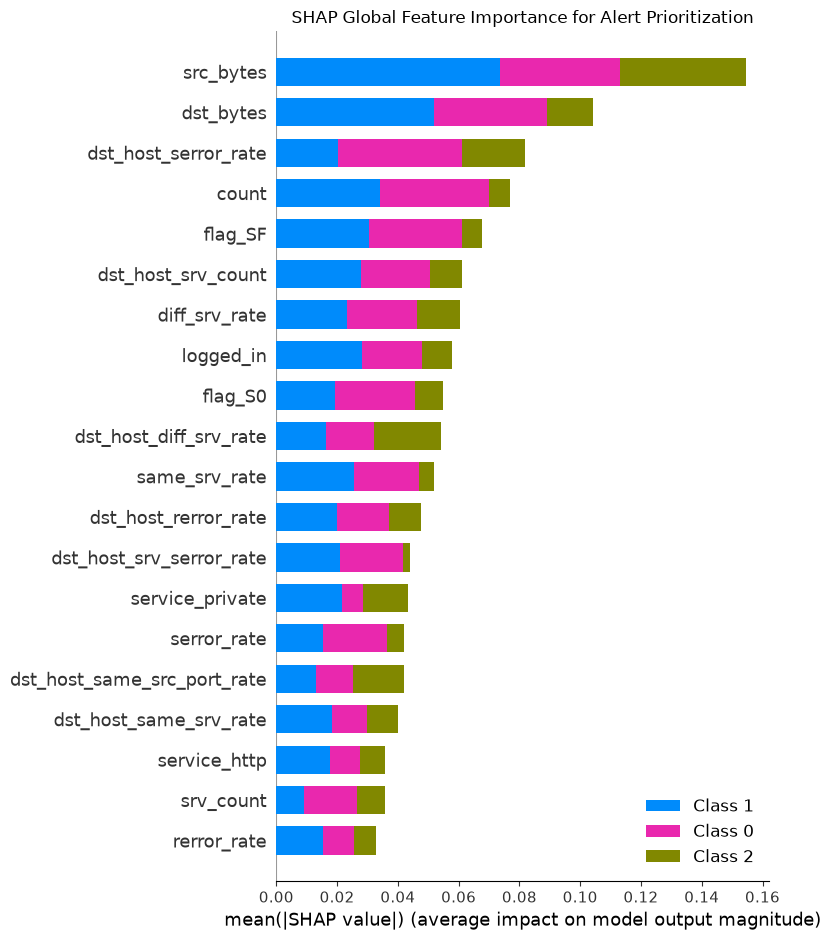

In [22]:
# ============================================================
# SHAP analysis (unchanged logic, now on real test set)
# ============================================================
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(model)
X_test_sample = X_test.iloc[:500]
shap_values = explainer.shap_values(X_test_sample)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_sample, plot_type="bar", show=False)
plt.title("SHAP Global Feature Importance for Alert Prioritization", fontsize=12)
plt.tight_layout()
plt.savefig('shap_summary_plot.png', dpi=300)
plt.show()

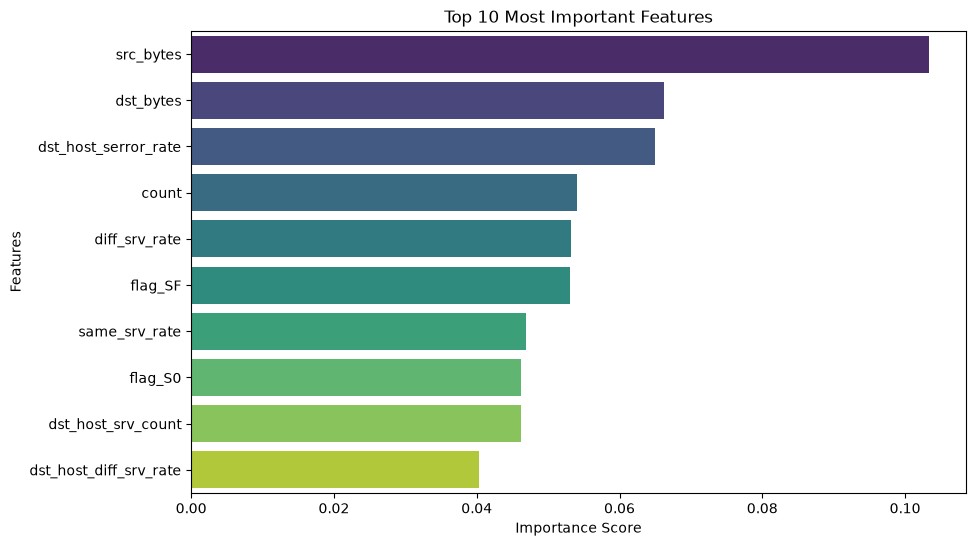

In [23]:
# ============================================================
# Feature importance bar chart
# ============================================================
import seaborn as sns

importances = model.feature_importances_
feature_names = X_train.columns

feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
top_10_features = feature_imp_df.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=top_10_features, hue='Feature', palette='viridis', legend=False)
plt.title('Top 10 Most Important Features')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.savefig("feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 800x600 with 0 Axes>

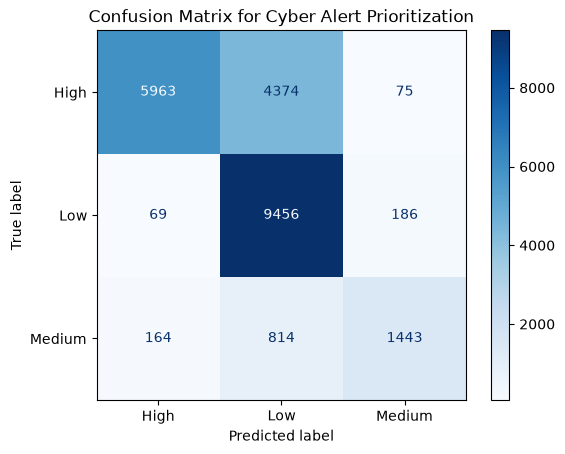

In [24]:
# ============================================================
# Confusion matrix
# ============================================================
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix for Cyber Alert Prioritization')
plt.savefig('Confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

In [25]:
# ============================================================
# Feature ablation test (drop four dominant features)
# ============================================================
dominant_features = ['src_bytes', 'dst_bytes', 'dst_host_serror_rate', 'diff_srv_rate']

X_train_hidden = X_train.drop(columns=dominant_features)
X_test_hidden = X_test.drop(columns=dominant_features)

hidden_threat_model = RandomForestClassifier(random_state=42)
hidden_threat_model.fit(X_train_hidden, y_train)
y_pred_hidden = hidden_threat_model.predict(X_test_hidden)

print("Accuracy Without Dominant Features:", accuracy_score(y_test, y_pred_hidden))
print("\nClassification Report:\n", classification_report(y_test, y_pred_hidden))

Accuracy Without Dominant Features: 0.7418825408090844

Classification Report:
               precision    recall  f1-score   support

        High       0.96      0.56      0.71     10412
         Low       0.64      0.97      0.77      9711
      Medium       0.81      0.58      0.67      2421

    accuracy                           0.74     22544
   macro avg       0.80      0.71      0.72     22544
weighted avg       0.81      0.74      0.73     22544



In [26]:
# ============================================================
# Multi-seed variance check (Feature Ablation Test)
# ============================================================
ablation_accuracies = []

for seed in seeds:  # reuses the same seeds list from the earlier variance cell
    model_ablated_seed = RandomForestClassifier(random_state=seed)
    model_ablated_seed.fit(X_train_hidden, y_train)
    acc = accuracy_score(y_test, model_ablated_seed.predict(X_test_hidden))
    ablation_accuracies.append(acc)
    print(f"Seed {seed}: {acc:.4f}")

print(f"\nMean ablation accuracy: {np.mean(ablation_accuracies):.4f} ± {np.std(ablation_accuracies):.4f}")

Seed 42: 0.7419
Seed 7: 0.7414
Seed 123: 0.7429
Seed 2024: 0.7410
Seed 99: 0.7415

Mean ablation accuracy: 0.7417 ± 0.0006


In [27]:
# ============================================================
# Gaussian noise robustness test
# ============================================================
X_test_adversarial = X_test.copy()

# Only inject noise into truly continuous traffic features, not
# already-binary flags or one-hot dummy columns
continuous_features = [
    'duration', 'src_bytes', 'dst_bytes', 'count', 'srv_count',
    'dst_host_count', 'dst_host_srv_count'
]

np.random.seed(42)
noise = np.random.normal(0, 0.1, size=X_test_adversarial[continuous_features].shape)
X_test_adversarial[continuous_features] += noise

y_pred_adv = model.predict(X_test_adversarial)

print("=" * 60)
print(" STRESS TEST: SYSTEM RESILIENCE AGAINST INJECTED NOISE ")
print("=" * 60)
print(f"Adversarial Testing Accuracy: {accuracy_score(y_test, y_pred_adv):.4f}")

 STRESS TEST: SYSTEM RESILIENCE AGAINST INJECTED NOISE 
Adversarial Testing Accuracy: 0.7480


In [28]:
# ============================================================
# Gaussian noise robustness test — RESCALED to each feature's std dev
# ============================================================
X_test_adversarial_scaled = X_test.copy()

np.random.seed(42)
for col in continuous_features:
    std = X_train[col].std()
    noise = np.random.normal(0, 0.1 * std, size=len(X_test_adversarial_scaled))
    X_test_adversarial_scaled[col] = X_test_adversarial_scaled[col] + noise

y_pred_adv_scaled = model.predict(X_test_adversarial_scaled)

print("=" * 60)
print(" STRESS TEST: RESCALED NOISE (σ = 0.1 × feature std dev) ")
print("=" * 60)
print(f"Rescaled-noise Testing Accuracy: {accuracy_score(y_test, y_pred_adv_scaled):.4f}")

 STRESS TEST: RESCALED NOISE (σ = 0.1 × feature std dev) 
Rescaled-noise Testing Accuracy: 0.7067


In [29]:
# ============================================================
# Multi-seed variance check (Rescaled Noise Test)
# ============================================================
noise_accuracies = []

for seed in seeds:  # reuses the same seeds list
    model_noise_seed = RandomForestClassifier(random_state=seed)
    model_noise_seed.fit(X_train, y_train)

    np.random.seed(seed)
    X_test_noisy_seed = X_test.copy()
    for col in continuous_features:
        std = X_train[col].std()
        noise = np.random.normal(0, 0.1 * std, size=len(X_test_noisy_seed))
        X_test_noisy_seed[col] = X_test_noisy_seed[col] + noise

    acc = accuracy_score(y_test, model_noise_seed.predict(X_test_noisy_seed))
    noise_accuracies.append(acc)
    print(f"Seed {seed}: {acc:.4f}")

print(f"\nMean rescaled-noise accuracy: {np.mean(noise_accuracies):.4f} ± {np.std(noise_accuracies):.4f}")

Seed 42: 0.7067
Seed 7: 0.7112
Seed 123: 0.7061
Seed 2024: 0.7043
Seed 99: 0.7036

Mean rescaled-noise accuracy: 0.7064 ± 0.0027


Total Alerts Processed: 22544
Total Inference Time: 0.5595 seconds
Inference Latency Per Alert: 0.0248 ms


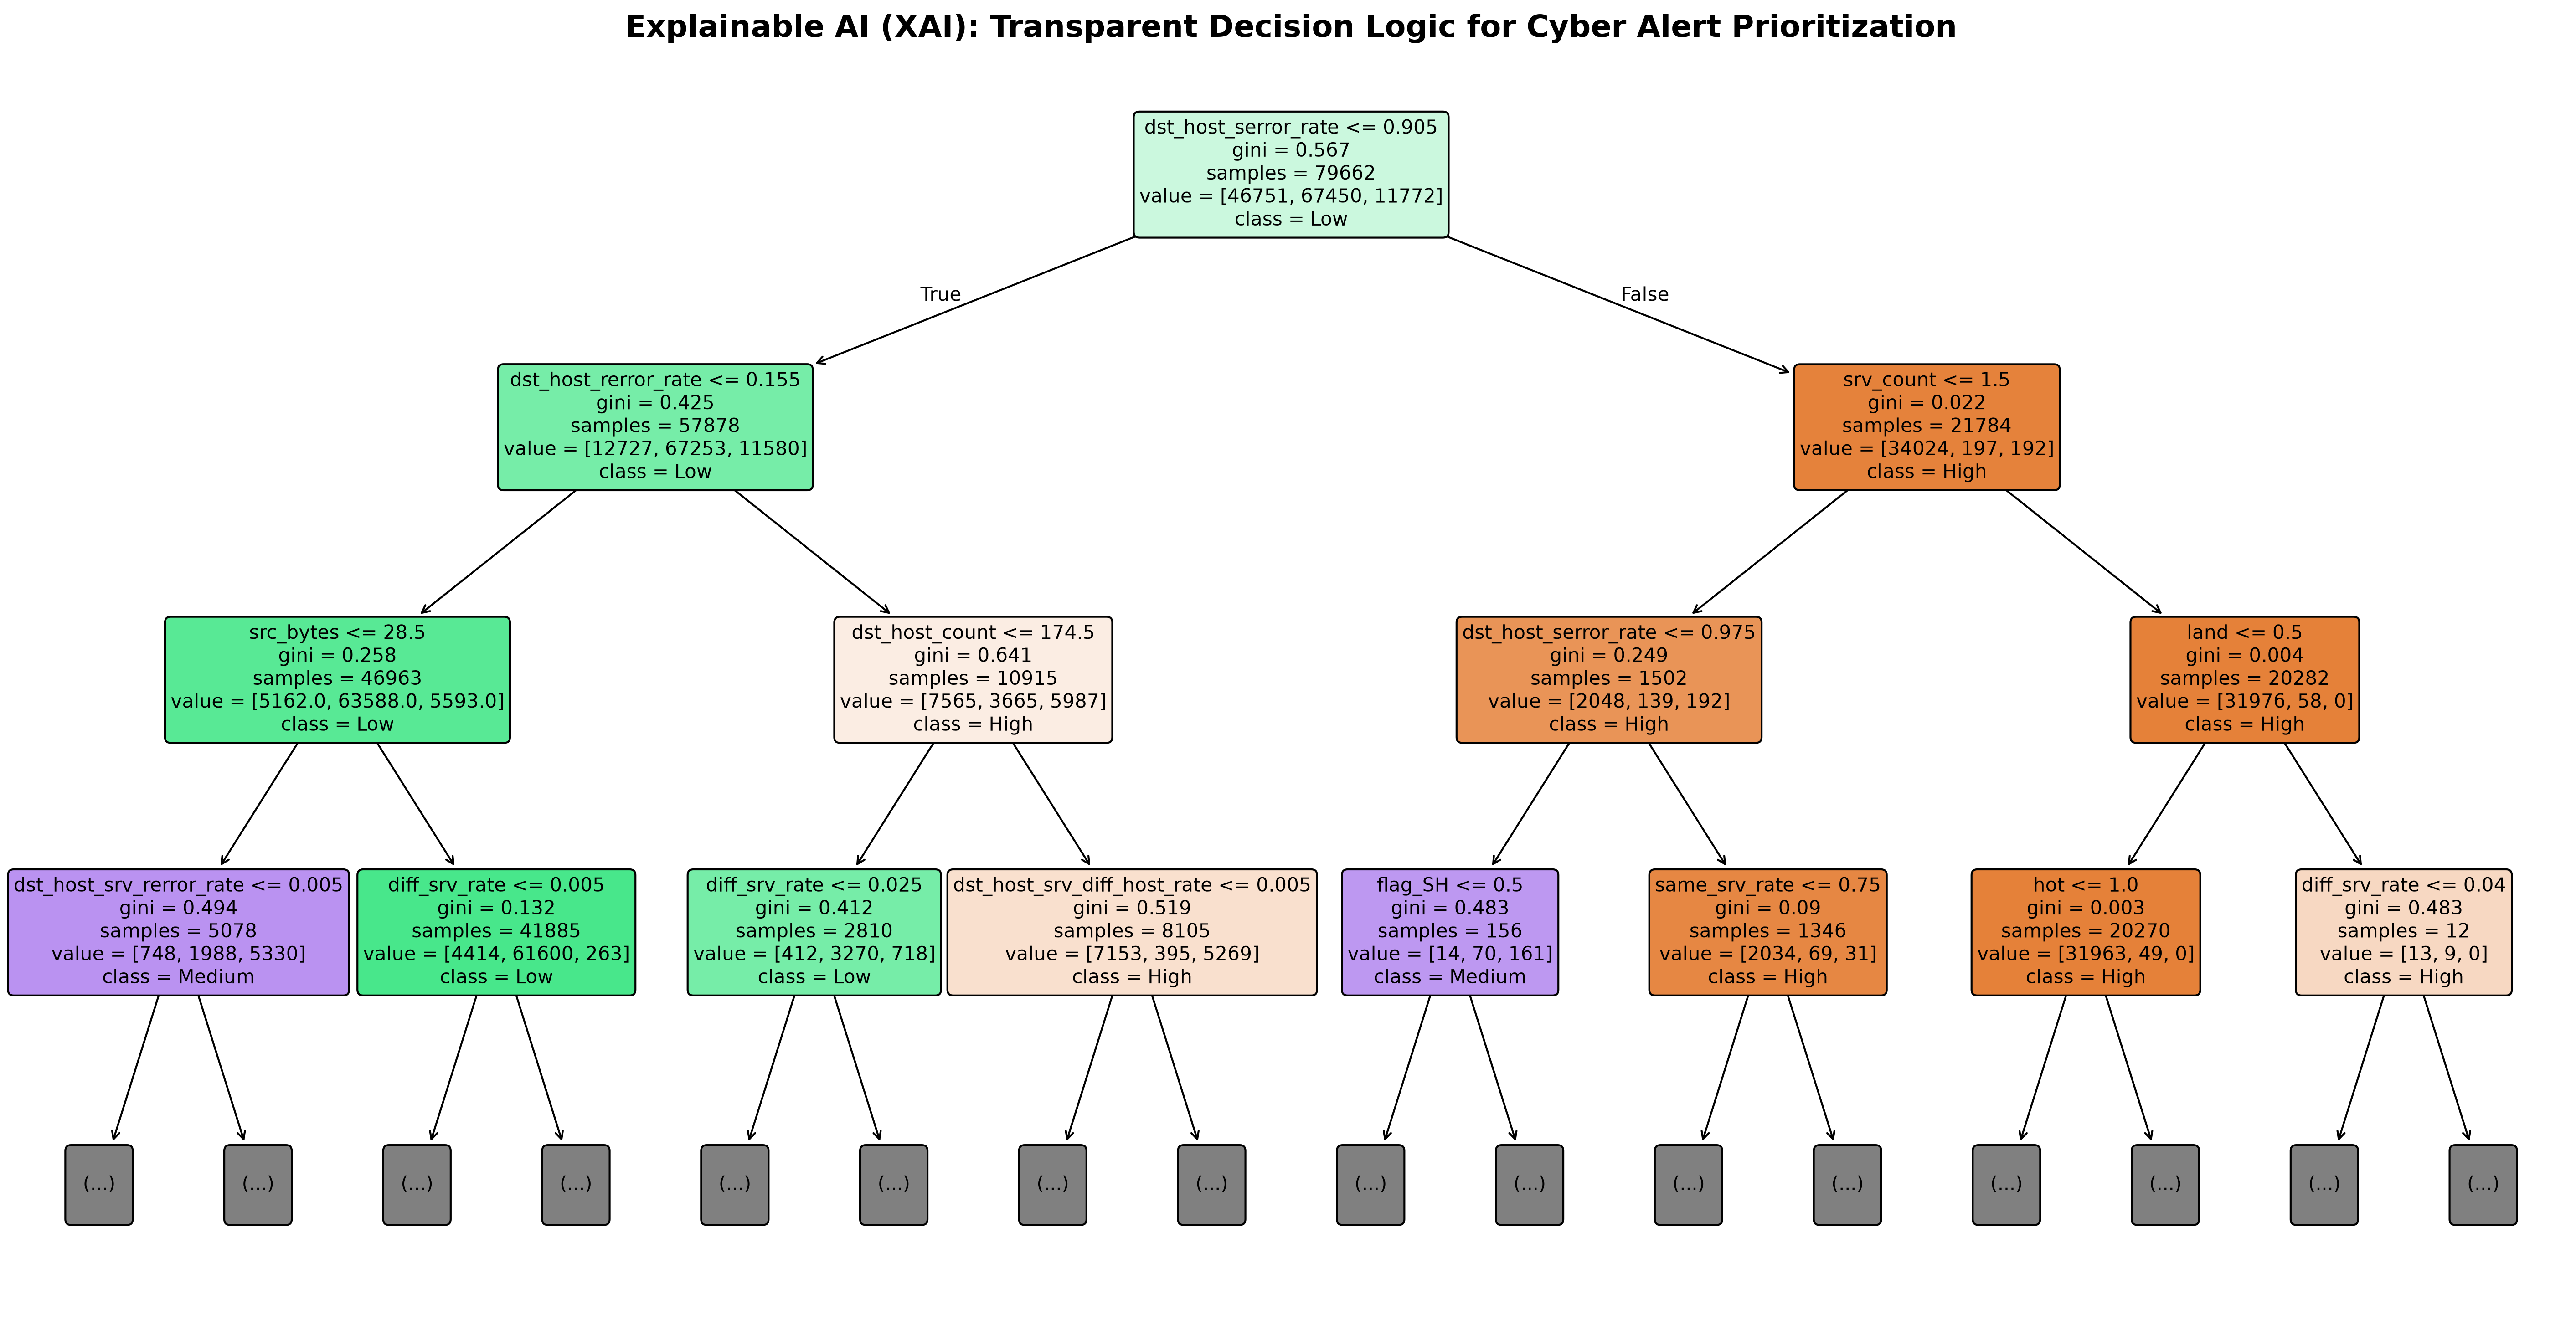

In [30]:
# ============================================================
# Inference latency + decision tree visualization
# ============================================================
import time
from sklearn.tree import plot_tree

total_alerts = len(X_test)
start_time = time.time()
_ = model.predict(X_test)
end_time = time.time()

total_inference_time = end_time - start_time
latency_per_alert_ms = (total_inference_time / total_alerts) * 1000

print(f"Total Alerts Processed: {total_alerts}")
print(f"Total Inference Time: {total_inference_time:.4f} seconds")
print(f"Inference Latency Per Alert: {latency_per_alert_ms:.4f} ms")

estimator = model.estimators_[0]
plt.figure(figsize=(24, 12), dpi=300)
plot_tree(estimator,
          max_depth=3,
          feature_names=list(X_train.columns),
          class_names=[str(c) for c in model.classes_],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Explainable AI (XAI): Transparent Decision Logic for Cyber Alert Prioritization",
          fontsize=16, fontweight='bold')
plt.savefig('xai_decision_tree.png', bbox_inches='tight')
plt.show()